## Assignment Task:-
1. Load the Dataset
2. Data Preprocessing:-
    - Handle Missing Values
    - Encode Categorical Variables
    - **Feature Scaling**:- Features = A, B, C, D & Target = E (Binary Classification)
    - Train-Test Split
3. **Train Models**:-
    - Logistic Regression
    - KNN
    - Naive Bayes
    - SVM
    - Gaussian Naïve Bayes
    - Bernoulli Naïve Bayes
    - Multinomial Naïve Bayes
    - Decision Tree Classifier
    - Random Forest Classifier
    - Extra Trees Classifier
    - Gradient Boosting Classifier
    - AdaBoost Classifier
    - XGBoost Classifier    - 
4. Compare Accuracy
5. Compare Precision
6. Compare Recall
7. Compare F1 Score
8. Compare ROC-AUC
9. Select Best Model
10. Apply GridSearchCV
11. Hyperparameter Tuning
12. Retrain Best Model
13. Predict on New Data
14. Save Model (joblib/pickle)

### Follows the full assignment pipeline: 
> **Load → Preprocess → Train 13 models → Compare 5 metrics → Select Best → GridSearchCV → Retrain → Predict → Save**

In [5]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 2.6/69.5 MB 15.4 MB/s eta 0:00:05
   -- ------------------------------------- 4.7/69.5 MB 12.1 MB/s eta 0:00:06
   --- ------------------------------------ 6.0/69.5 MB 10.0 MB/s eta 0:00:07
   --- ------------------------------------ 6.8/69.5 MB 8.8 MB/s eta 0:00:08
   ---- ----------------------------------- 7.6/69.5 MB 7.3 MB/s eta 0:00:09
   ---- ----------------------------------- 8.4/69.5 MB 6.8 MB/s eta 0:00:09
   ----- ---------------------------------- 8.9/69.5 MB 6.2 MB/s eta 0:00:10
   ----- ---------------------------------- 9.7/69.5 MB 5.7 MB/s eta 0:00:11
   ------ --------------------------------- 10.5/69.5 MB 5.4 MB/s eta 0:00:12
   ------ --------------------------------- 11.0/69.5 MB 5.1 MB/s eta 0:00:12
   ------ --------------------------------- 11.8/69.5 MB 4.9 MB/s eta 0:00:12
   ------- -------------------------------- 12.3/69.5 MB 4.8 MB/s eta 0:00:12

In [18]:
# Import All Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


# ==============================
# Step 1 — Load the Dataset
# ==============================

In [19]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (400, 5)


In [20]:
# Summary of Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [21]:
df.describe(include='all')

,User ID,Gender,Age,EstimatedSalary,Purchased
count,4.000000e+02,400,400.000000,400.000000,400.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,204,NaN,NaN,NaN
mean,1.569154e+07,NaN,37.655000,69742.500000,0.357500
std,7.165832e+04,NaN,10.482877,34096.960282,0.479864
min,1.556669e+07,NaN,18.000000,15000.000000,0.000000
25%,1.562676e+07,NaN,29.750000,43000.000000,0.000000
50%,1.569434e+07,NaN,37.000000,70000.000000,0.000000
75%,1.575036e+07,NaN,46.000000,88000.000000,1.000000


# ==============================
# Step 2 — Data Preprocessing
# ==============================

### 2a. Handle Missing Values

In [22]:
print("Missing values per column:\n", df.isnull().sum())

# If any missing values existed, we'd impute like this (kept here for completeness / robustness):
if df.isnull().sum().sum() > 0:
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['EstimatedSalary'] = df['EstimatedSalary'].fillna(df['EstimatedSalary'].median())
    df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
    print("Missing values imputed.")
else:
    print("No missing values found — nothing to impute.")

Missing values per column:
 User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
No missing values found — nothing to impute.


### 2b. Encode Categorical Variables (`Gender`)

In [23]:
le_gender = LabelEncoder()
df['Gender_Encoded'] = le_gender.fit_transform(df['Gender'])  # Female=0, Male=1
print(dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
df[['Gender', 'Gender_Encoded']].drop_duplicates()

{'Female': np.int64(0), 'Male': np.int64(1)}


,Gender,Gender_Encoded
0,Male,1
2,Female,0


### 2c. Define Features (A, B, C) and Target (E)
`User ID` is dropped — it's a unique identifier with no predictive signal.

In [24]:
FEATURES = ['Gender_Encoded', 'Age', 'EstimatedSalary']
TARGET = 'Purchased'

X = df[FEATURES].values
y = df[TARGET].values

print("X shape:", X.shape, "| y shape:", y.shape)
print("Class balance:\n", df[TARGET].value_counts(normalize=True))

X shape: (400, 3) | y shape: (400,)
Class balance:
 Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64


### 2d. Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (300, 3) | Test: (100, 3)


### 2e. Feature Scaling
Fit the scaler on **training data only**, then apply to both sets (prevents test-set leakage).

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean (train, post-scaling):", X_train_scaled.mean(axis=0).round(3))
print("Std  (train, post-scaling):", X_train_scaled.std(axis=0).round(3))

Mean (train, post-scaling): [ 0. -0.  0.]
Std  (train, post-scaling): [1. 1. 1.]


# ==============================
# Step 3 — Train Models
# ==============================

### For Every Model Do this:-
> 1. Create Model
> 2. Train Model
> 3. Predict
> 4. Predict Probability (or Decision Function)
> 5. Calculate Metrics
> 6. Store Results
> 7. Save Trained Model

In [27]:
# Store evaluation results
results = []

# Store trained models
fitted_models = {}

### 1. Logistic Regression:- 

In [28]:
from sklearn.linear_model import LogisticRegression

# Create Model
log_reg = LogisticRegression(random_state=RANDOM_STATE)

# Train Model
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred = log_reg.predict(X_test_scaled)

# Predict Probability
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Store Model
fitted_models["Logistic Regression"] = log_reg

# Store Results
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
})

### 2. KNN:- 

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

y_proba = knn.predict_proba(X_test_scaled)[:,1]

fitted_models["KNN"] = knn

results.append({
    "Model":"KNN",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

### 3. SVM:- 

In [30]:
from sklearn.svm import SVC

svm = SVC(
    probability=True,
    random_state=RANDOM_STATE
)

svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

y_proba = svm.predict_proba(X_test_scaled)[:,1]

fitted_models["SVM"] = svm

results.append({
    "Model":"SVM",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

### 4. Gaussian Naive Bayes:- 

In [31]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)

y_pred = gnb.predict(X_test_scaled)

y_proba = gnb.predict_proba(X_test_scaled)[:,1]

fitted_models["Gaussian Naive Bayes"] = gnb

results.append({
    "Model":"Gaussian Naive Bayes",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

### 5. Bernoulli Naive Bayes:- 

In [32]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()

bnb.fit(X_train_scaled, y_train)

y_pred = bnb.predict(X_test_scaled)

y_proba = bnb.predict_proba(X_test_scaled)[:,1]

fitted_models["Bernoulli Naive Bayes"] = bnb

results.append({
    "Model":"Bernoulli Naive Bayes",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

### 6. Multinomial Naive Bayes:- 

In [34]:
# 1. Create X_train_mm and X_test_mm
from sklearn.preprocessing import MinMaxScaler

# Create MinMaxScaler object
mm_scaler = MinMaxScaler()

# Scale training data
X_train_mm = mm_scaler.fit_transform(X_train)

# Scale test data
X_test_mm = mm_scaler.transform(X_test)

In [35]:
# 2. Train Multinomial Naïve Bayes

from sklearn.naive_bayes import MultinomialNB

# Create model
mnb = MultinomialNB()

# Train model
mnb.fit(X_train_mm, y_train)

# Predict
y_pred = mnb.predict(X_test_mm)

# Predict probability
y_proba = mnb.predict_proba(X_test_mm)[:, 1]

print("Multinomial Naive Bayes Trained Successfully")

Multinomial Naive Bayes Trained Successfully


In [36]:
# Verify that X_train_mm exists or not?
print(X_train_mm.shape)
print(X_test_mm.shape)

(300, 3)
(100, 3)


### 7. Decision Tree Classifier:- 

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt.fit(X_train_scaled, y_train)

y_pred = dt.predict(X_test_scaled)

y_proba = dt.predict_proba(X_test_scaled)[:,1]

fitted_models["Decision Tree"] = dt

results.append({
    "Model":"Decision Tree",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

### 8. Random Forest Classifier:- 

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

y_proba = rf.predict_proba(X_test_scaled)[:,1]

fitted_models["Random Forest"] = rf

results.append({
    "Model":"Random Forest",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

### 9. Extra Trees Classifier:- 

In [39]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(random_state=RANDOM_STATE)

et.fit(X_train_scaled, y_train)

y_pred = et.predict(X_test_scaled)

y_proba = et.predict_proba(X_test_scaled)[:,1]

fitted_models["Extra Trees"] = et

results.append({
    "Model":"Extra Trees",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

### 10. Gradient Boosting Classifier:- 

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb.fit(X_train_scaled, y_train)

y_pred = gb.predict(X_test_scaled)

y_proba = gb.predict_proba(X_test_scaled)[:,1]

fitted_models["Gradient Boosting"] = gb

results.append({
    "Model":"Gradient Boosting",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

### 11. AdaBoost Classifier:- 

In [41]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=RANDOM_STATE)

ada.fit(X_train_scaled, y_train)

y_pred = ada.predict(X_test_scaled)

y_proba = ada.predict_proba(X_test_scaled)[:,1]

fitted_models["AdaBoost"] = ada

results.append({
    "Model":"AdaBoost",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

### 12. XGBoost Classifier:- 

In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

xgb.fit(X_train_scaled, y_train)

y_pred = xgb.predict(X_test_scaled)

y_proba = xgb.predict_proba(X_test_scaled)[:,1]

fitted_models["XGBoost"] = xgb

results.append({
    "Model":"XGBoost",
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred,zero_division=0),
    "Recall":recall_score(y_test,y_pred,zero_division=0),
    "F1 Score":f1_score(y_test,y_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,y_proba)
})

In [45]:
models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes (Gaussian)": GaussianNB(),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB(),
    "Bernoulli Naive Bayes": BernoulliNB(),
    "Multinomial Naive Bayes": MultinomialNB(),  # requires non-negative input, handled below
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
    "Linear Regression (0.5 threshold, bonus)": LinearRegression(),
}

# MultinomialNB needs non-negative features -> use MinMax-scaled version just for that model
from sklearn.preprocessing import MinMaxScaler
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

print(f"{len(models)} models ready to train.")

14 models ready to train.


In [46]:
results = []
fitted_models = {}

for name, model in models.items():
    # MultinomialNB needs non-negative inputs
    Xtr, Xte = (X_train_mm, X_test_mm) if name == "Multinomial Naive Bayes" else (X_train_scaled, X_test_scaled)

    model.fit(Xtr, y_train)
    fitted_models[name] = model

    if name.startswith("Linear Regression"):
        raw_pred = model.predict(Xte)
        y_pred = (raw_pred >= 0.5).astype(int)
        y_proba = np.clip(raw_pred, 0, 1)  # crude probability-like score for ROC-AUC
    else:
        y_pred = model.predict(Xte)
        y_proba = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(Xte)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,0.91,0.864865,0.888889,0.876712,0.911675
1,Extra Trees,0.91,0.864865,0.888889,0.876712,0.902561
2,SVM,0.90,0.842105,0.888889,0.864865,0.954861
3,Random Forest,0.90,0.842105,0.888889,0.864865,0.922309
4,Gradient Boosting,0.90,0.842105,0.888889,0.864865,0.944010
5,XGBoost,0.89,0.837838,0.861111,0.849315,0.925130
6,AdaBoost,0.89,0.878788,0.805556,0.840580,0.943793
7,Decision Tree,0.88,0.815789,0.861111,0.837838,0.875868
8,Naive Bayes (Gaussian),0.87,0.848485,0.777778,0.811594,0.947483
9,Gaussian Naive Bayes,0.87,0.848485,0.777778,0.811594,0.947483


### Compare Accuracy, Precision, Recall, F1 Score, ROC-AUC

> The table above already has all five metrics side by side. Below is a visual comparison & Representation.

# ==============================
# Step 4. Compare Accuracy
# ==============================

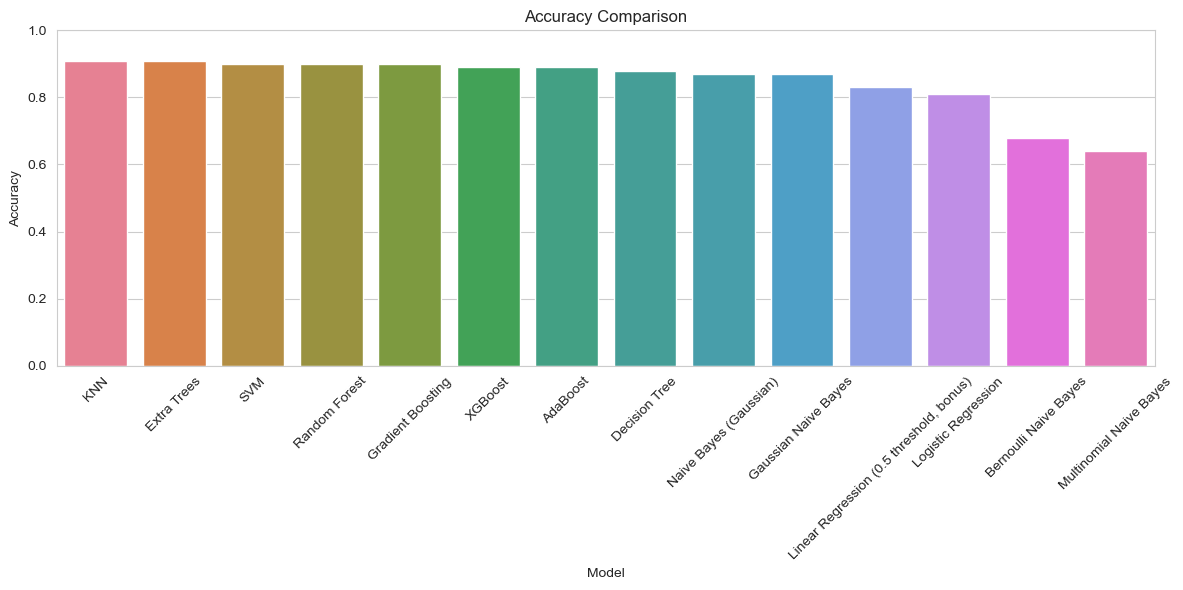

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    legend=False
)

plt.title("Accuracy Comparison")
plt.ylim(0,1)

# Rotate model names for better visibility
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==============================
# Step 5. Compare Precision
# ==============================

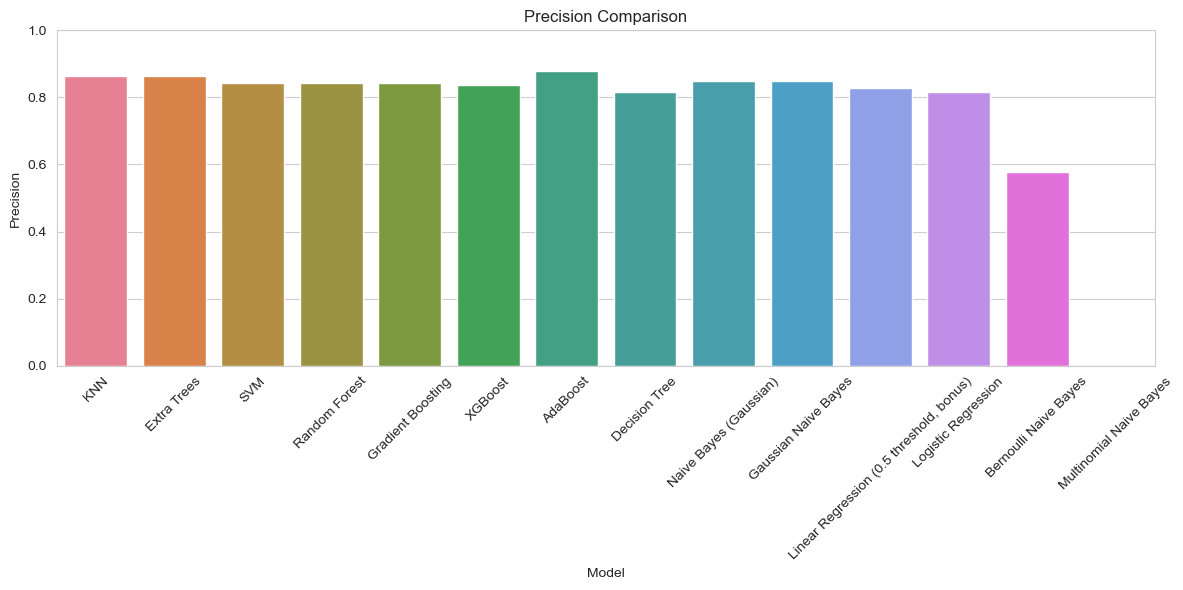

In [68]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision",
    hue="Model",
    legend=False
)

plt.title("Precision Comparison")
plt.ylim(0,1)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==============================
# Step 6. Compare Recall
# ==============================

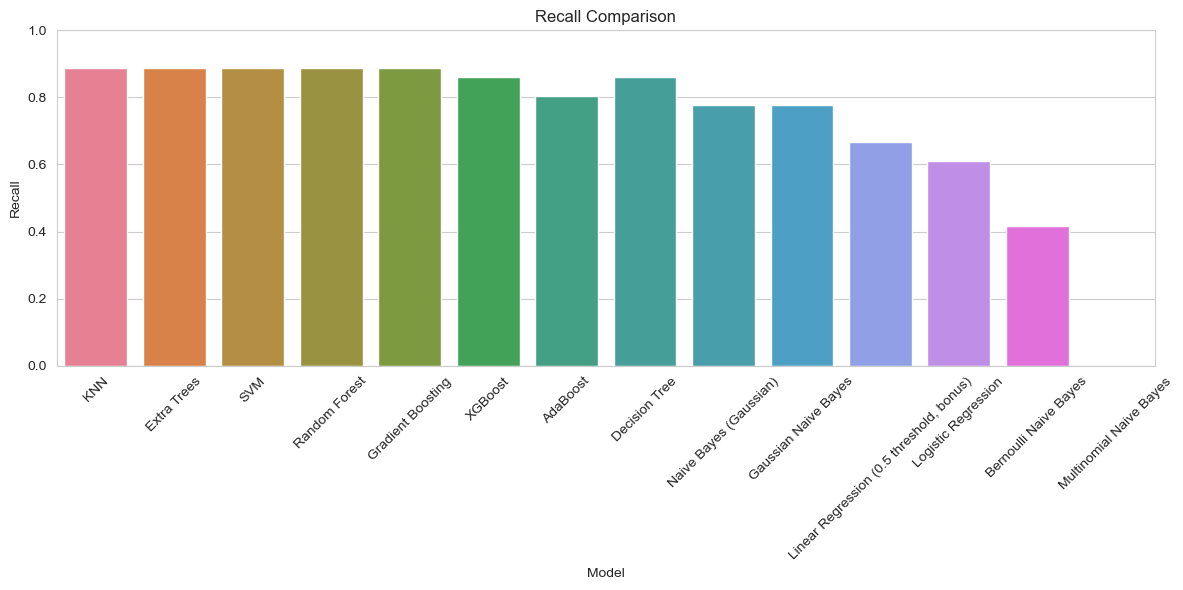

In [69]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall",
    hue="Model",
    legend=False
)

plt.title("Recall Comparison")
plt.ylim(0,1)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==============================
# Step 7. Compare F1 Score
# ==============================

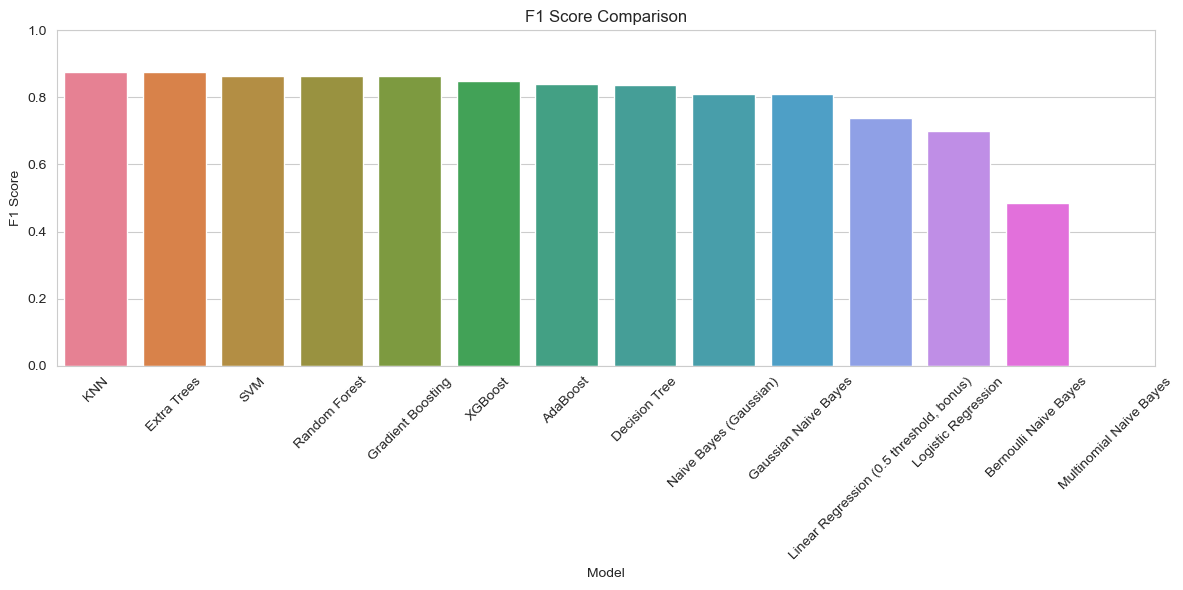

In [70]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    hue="Model",
    legend=False
)

plt.title("F1 Score Comparison")
plt.ylim(0,1)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==============================
# Step 8. Compare ROC-AUC
# ==============================

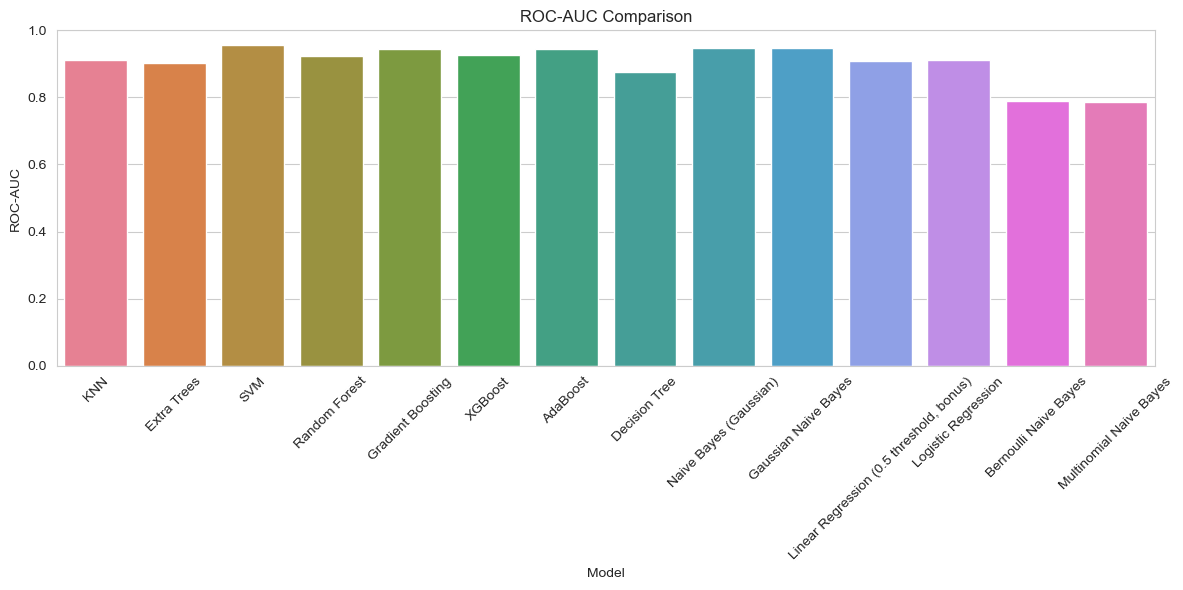

In [71]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC",
    hue="Model",
    legend=False
)

plt.title("ROC-AUC Comparison")
plt.ylim(0,1)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Combined Comparison Chart (Vertical Graph):-

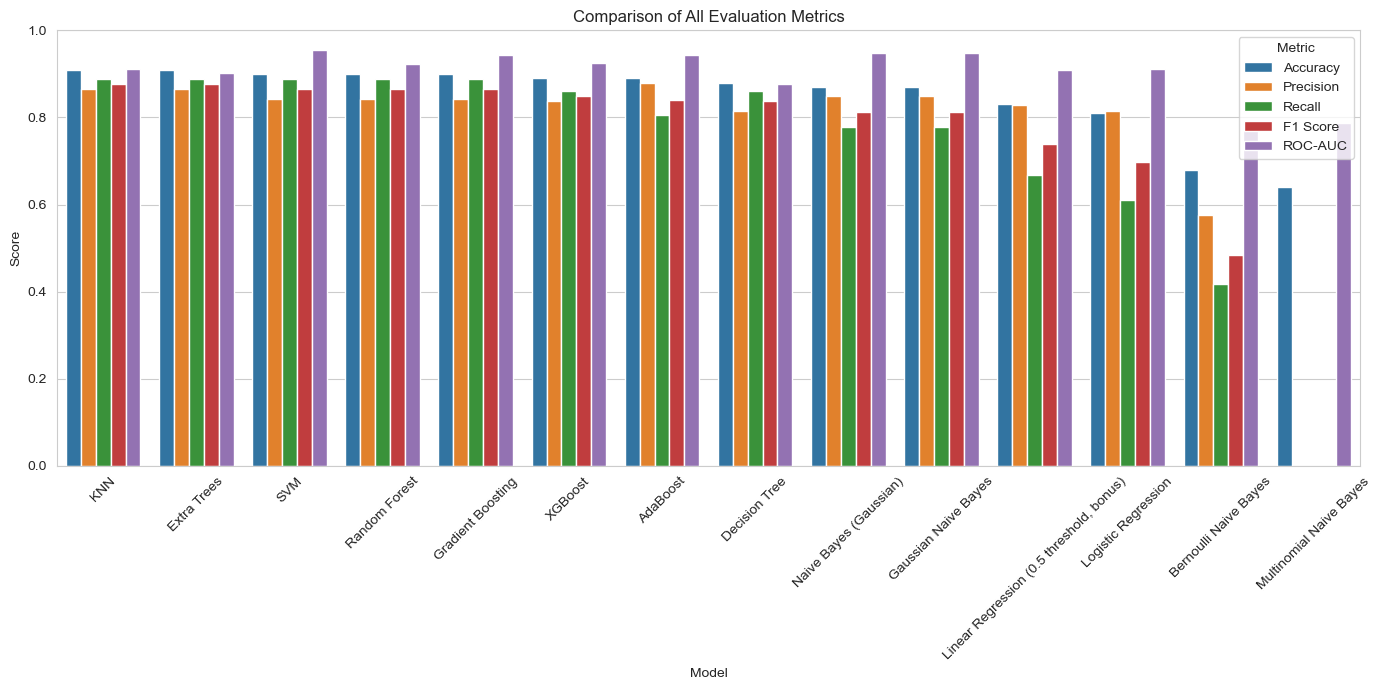

In [66]:
# Convert to long format
comparison_df = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of All Evaluation Metrics")
plt.ylim(0,1)

# Rotate model names for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==============================
# Step 9 — Select Best Model
# ==============================

In [72]:
best_model_name = results_df.sort_values(["F1 Score", "ROC-AUC"], ascending=False).iloc[0]["Model"]
print("Best model:", best_model_name)
results_df[results_df["Model"] == best_model_name]

Best model: KNN


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,0.91,0.864865,0.888889,0.876712,0.911675


# ==============================
# Steps 10–11 — GridSearchCV & Hyperparameter Tuning
# ==============================

> Parameter grids for every model in the comparison, so this cell works no matter which model came out on top.

In [77]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    },
    "Naive Bayes (Gaussian)": {"var_smoothing": [1e-9, 1e-8, 1e-7]},
    "Gaussian Naive Bayes": {"var_smoothing": [1e-9, 1e-8, 1e-7]},
    "Bernoulli Naive Bayes": {"alpha": [0.1, 0.5, 1.0, 2.0]},
    "Multinomial Naive Bayes": {"alpha": [0.1, 0.5, 1.0, 2.0]},
    "SVM": {
        "C": [0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "Decision Tree": {
        "criterion": ["gini", "entropy"],
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5]
    },
    "Extra Trees": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, None]
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [2, 3, 4]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1.0]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 4, 5]
    },
    "Linear Regression (0.5 threshold, bonus)": {
        "fit_intercept": [True, False]
    },
}

grid = param_grids[best_model_name]
base_model = type(models[best_model_name])()  # fresh, untrained instance of the winning model's class

Xtr_tune = X_train_mm if best_model_name == "Multinomial Naive Bayes" else X_train_scaled

grid_search = GridSearchCV(
    base_model, grid, cv=5, scoring="f1", n_jobs=-1, verbose=1
)
grid_search.fit(Xtr_tune, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Best CV F1 score: 0.8756


# ==============================
# Step 12 — Retrain Best Model (with tuned hyperparameters)
# ==============================

In [78]:
best_model = grid_search.best_estimator_

Xte_tune = X_test_mm if best_model_name == "Multinomial Naive Bayes" else X_test_scaled

y_pred_final = best_model.predict(Xte_tune)
y_proba_final = (best_model.predict_proba(Xte_tune)[:, 1]
                  if hasattr(best_model, "predict_proba")
                  else best_model.decision_function(Xte_tune))

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_final),
}
print(f"Tuned {best_model_name} — Test Set Performance:")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

Tuned KNN — Test Set Performance:
  Accuracy: 0.9100
  Precision: 0.8649
  Recall: 0.8889
  F1 Score: 0.8767
  ROC-AUC: 0.9117

Confusion Matrix:
 [[59  5]
 [ 4 32]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        64
           1       0.86      0.89      0.88        36

    accuracy                           0.91       100
   macro avg       0.90      0.91      0.90       100
weighted avg       0.91      0.91      0.91       100



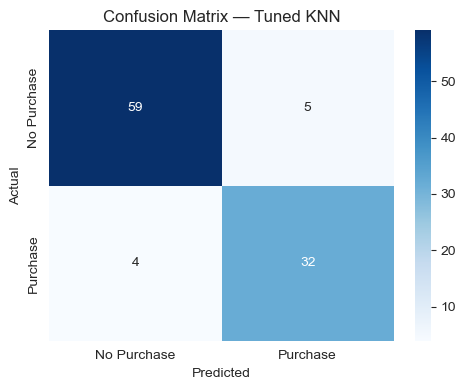

In [79]:
# Confusion Matrix - Tuned KNN
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'], yticklabels=['No Purchase', 'Purchase'])
plt.title(f'Confusion Matrix — Tuned {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

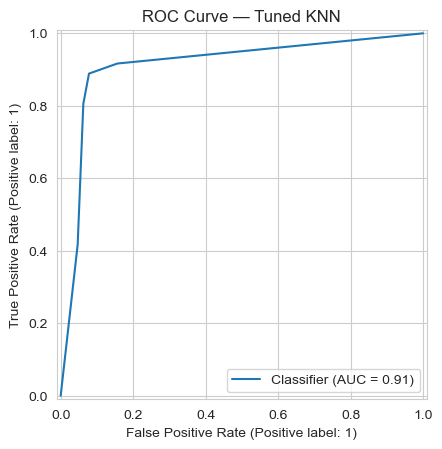

In [80]:
RocCurveDisplay.from_predictions(y_test, y_proba_final)
plt.title(f'ROC Curve — Tuned {best_model_name}')
plt.show()

# ==============================
# Step 13 — Predict on New Data
# ==============================

> Example: a 35-year-old Male with an estimated salary of 87,000.

In [81]:
new_data = pd.DataFrame({
    'Gender': ['Male'],
    'Age': [35],
    'EstimatedSalary': [87000]
})

new_data['Gender_Encoded'] = le_gender.transform(new_data['Gender'])
new_X = new_data[FEATURES].values

new_X_scaled = mm_scaler.transform(new_X) if best_model_name == "Multinomial Naive Bayes" else scaler.transform(new_X)

prediction = best_model.predict(new_X_scaled)[0]
proba = (best_model.predict_proba(new_X_scaled)[0, 1]
         if hasattr(best_model, "predict_proba") else None)

print("Predicted class:", "Will Purchase" if prediction == 1 else "Will Not Purchase")
if proba is not None:
    print(f"Predicted probability of purchase: {proba:.2%}")

Predicted class: Will Not Purchase
Predicted probability of purchase: 40.00%


# ==============================
# Step 14 — Save Model
# ==============================

> Saves the tuned model plus the preprocessing objects (encoder + scaler) — you need all three to make predictions on fresh raw data later.

In [82]:
import pickle

# joblib (recommended for sklearn models)
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le_gender, 'gender_encoder.joblib')

# pickle (alternative)
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"Saved: best_model.joblib / .pkl  (model = {best_model_name})")
print("Saved: scaler.joblib, gender_encoder.joblib")

Saved: best_model.joblib / .pkl  (model = KNN)
Saved: scaler.joblib, gender_encoder.joblib


In [83]:
# Reload and confirm predictions match
reloaded_model = joblib.load('best_model.joblib')
reloaded_scaler = joblib.load('scaler.joblib')
reloaded_encoder = joblib.load('gender_encoder.joblib')

check_pred = reloaded_model.predict(new_X_scaled)[0]
assert check_pred == prediction, "Mismatch after reload!"
print("Reload check passed — saved model reproduces the same prediction.")

Reload check passed — saved model reproduces the same prediction.
